# 1.5.2 Harris Corner Detection

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [5]:
filename = 'sim0.png'
img = cv2.imread(filename)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray,2,3,0.04)

In [6]:
#result is dilated for marking the corners, not important
dst = cv2.dilate(dst,None)
# Threshold for an optimal value, it may vary depending on the image.
img[dst>0.1*dst.max()]=[255,0,0]

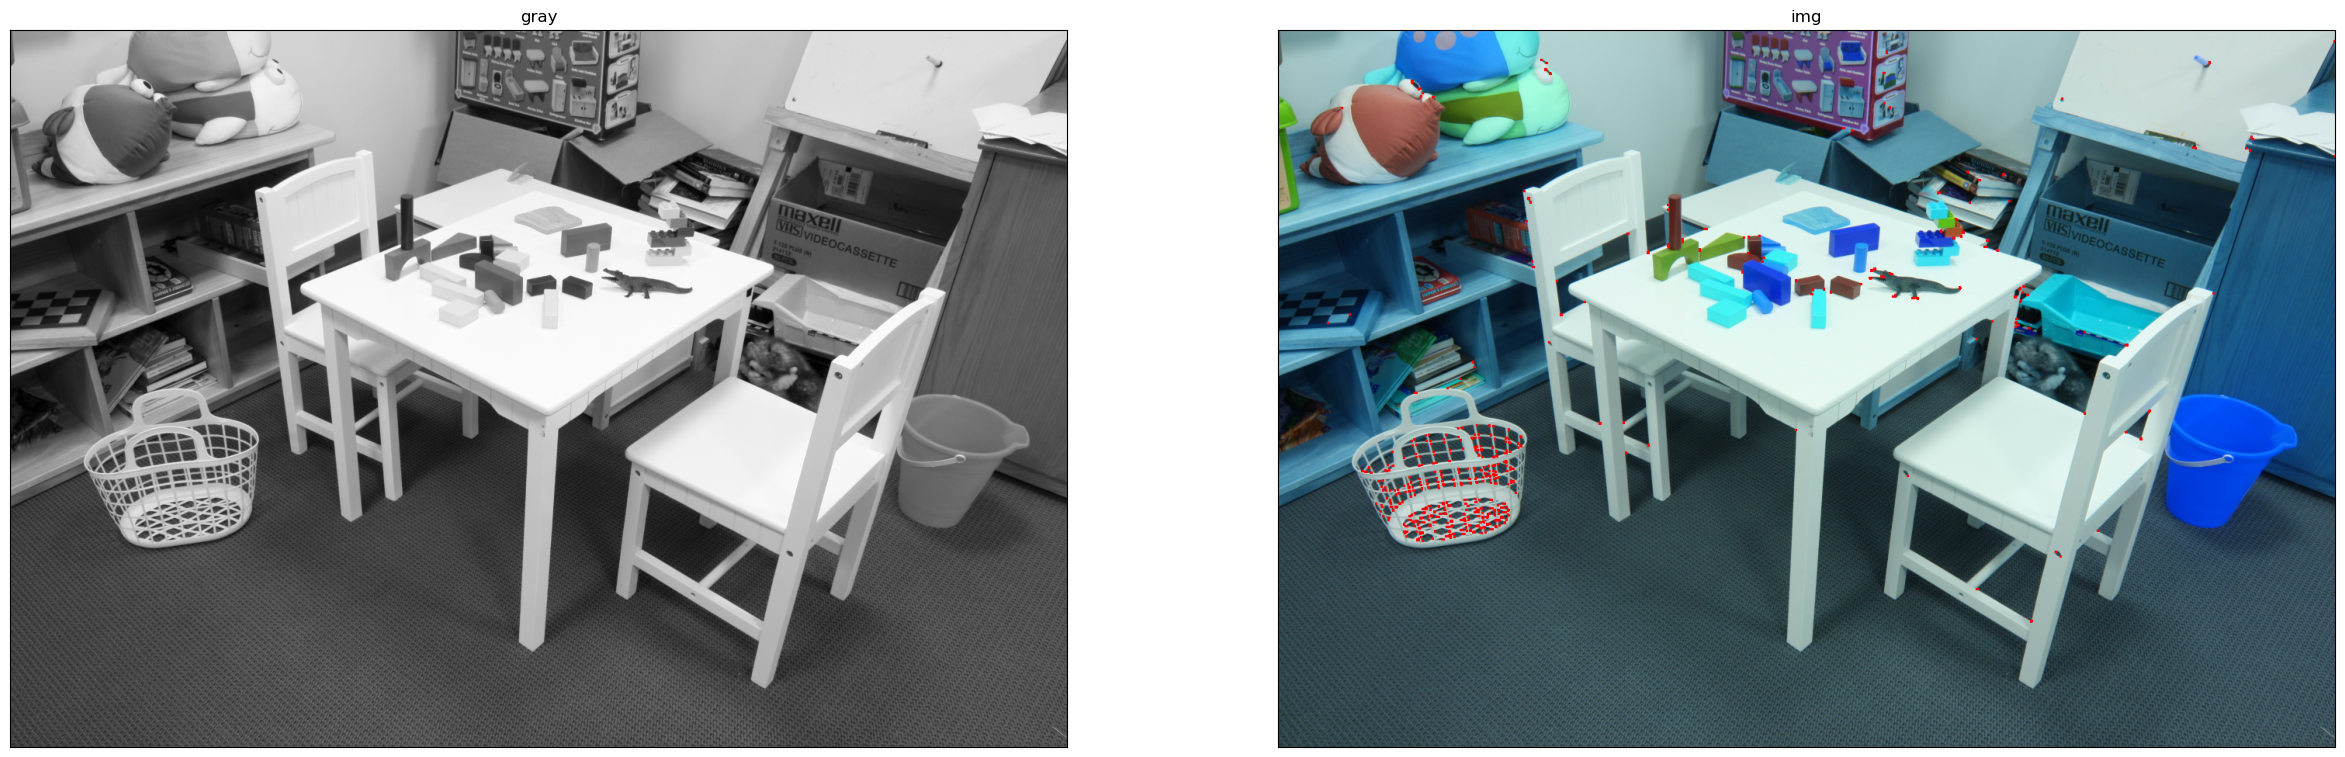

In [7]:
plt.figure(figsize = (30,45))
plt.subplot(1,2,1),plt.imshow(gray,cmap = 'gray')
plt.title('gray'), plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2),plt.imshow(img,cmap = 'gray')
plt.title('img'), plt.xticks([]), plt.yticks([])
plt.show()

## with Trackbar

In [8]:
#result is dilated for marking the corners, not important
dst = cv2.dilate(dst,None)

In [9]:
def nothing(x):
    pass

In [12]:
cv2.namedWindow('image')
cv2.createTrackbar('threshold', 'image', 10, 1000, nothing)
while(1):
    k = cv2.waitKey(1) & 0xFF
    if k == 27:
        break
    threshold = cv2.getTrackbarPos('threshold', 'image')
    if(threshold <= 1):
        threshold=1
    img = cv2.imread(filename)
    img[dst>threshold/1000.*dst.max()]=[0,0,255]
    cv2.imshow('image',img)
cv2.destroyAllWindows()

## Corner with SubPixel Accuracy

In [13]:
import cv2
import numpy as np

In [14]:
filename = 'sim0.png' #sIMG_2164.jpg horse-beach.bmp
img = cv2.imread(filename)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

In [15]:
# find Harris corners
gray = np.float32(gray)
dst = cv2.cornerHarris(gray,2,3,0.04)
#dst = cv2.dilate(dst,None)
ret, dst = cv2.threshold(dst,0.2*dst.max(),255,0)
dst = np.uint8(dst)
print(ret, dst.shape)

6209659.2 (924, 1362)


In [16]:
# find centroids
ret, labels, stats, centroids = cv2.connectedComponentsWithStats(dst)

In [17]:
# define the criteria to stop and refine the corners
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.001)
corners = cv2.cornerSubPix(gray,np.float32(centroids),(5,5),(-1,-1),criteria)

In [18]:
# Now draw them
res = np.hstack((centroids,corners))
res = np.int0(res)
print(res.shape)

(187, 4)


C:\Users\U303-13\AppData\Local\Temp\ipykernel_40800\1919363607.py:3: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  res = np.int0(res)


In [19]:
print(res)

[[ 680  461  676  463]
 [ 345   42  346   42]
 [ 345   50  343   49]
 [ 350   55  351   56]
 [ 172   67  171   64]
 [ 181   75  181   75]
 [ 199   86  200   85]
 [1254  137 1253  137]
 [1182  152 1181  151]
 [1252  155 1252  153]
 [ 888  183  885  181]
 [ 935  185  934  185]
 [ 903  193  903  191]
 [ 317  207  315  206]
 [ 850  209  848  208]
 [ 325  222  325  222]
 [ 550  256  550  256]
 [ 854  258  854  258]
 [ 882  260  881  258]
 [ 606  266  603  267]
 [ 880  266  880  266]
 [ 870  268  869  266]
 [ 521  271  519  271]
 [ 913  271  914  269]
 [ 503  277  503  276]
 [ 911  279  909  278]
 [ 543  283  541  284]
 [ 926  283  925  283]
 [ 476  286  475  286]
 [ 606  287  606  286]
 [ 329  305  328  305]
 [ 769  307  769  307]
 [ 764  309  763  308]
 [ 788  313  788  313]
 [ 763  319  761  318]
 [ 778  318  778  319]
 [ 667  322  662  324]
 [ 750  327  750  325]
 [ 703  333  703  333]
 [ 878  332  879  331]
 [ 955  333  957  329]
 [ 689  335  688  333]
 [ 687  340  687  339]
 [ 966  341

In [20]:
img = cv2.imread(filename)
oimg = cv2.imread(filename)
img[res[:,1],res[:,0]]=[255,0,0]
oimg[res[:,3],res[:,2]] = [0,255,0]

In [21]:
for i in range(res.shape[0]):
    cv2.circle(img,(res[i,0],res[i,1]),3,(255,0,0),-1)
    cv2.circle(oimg,(res[i,2],res[i,3]),5,(0,255,0),-1)

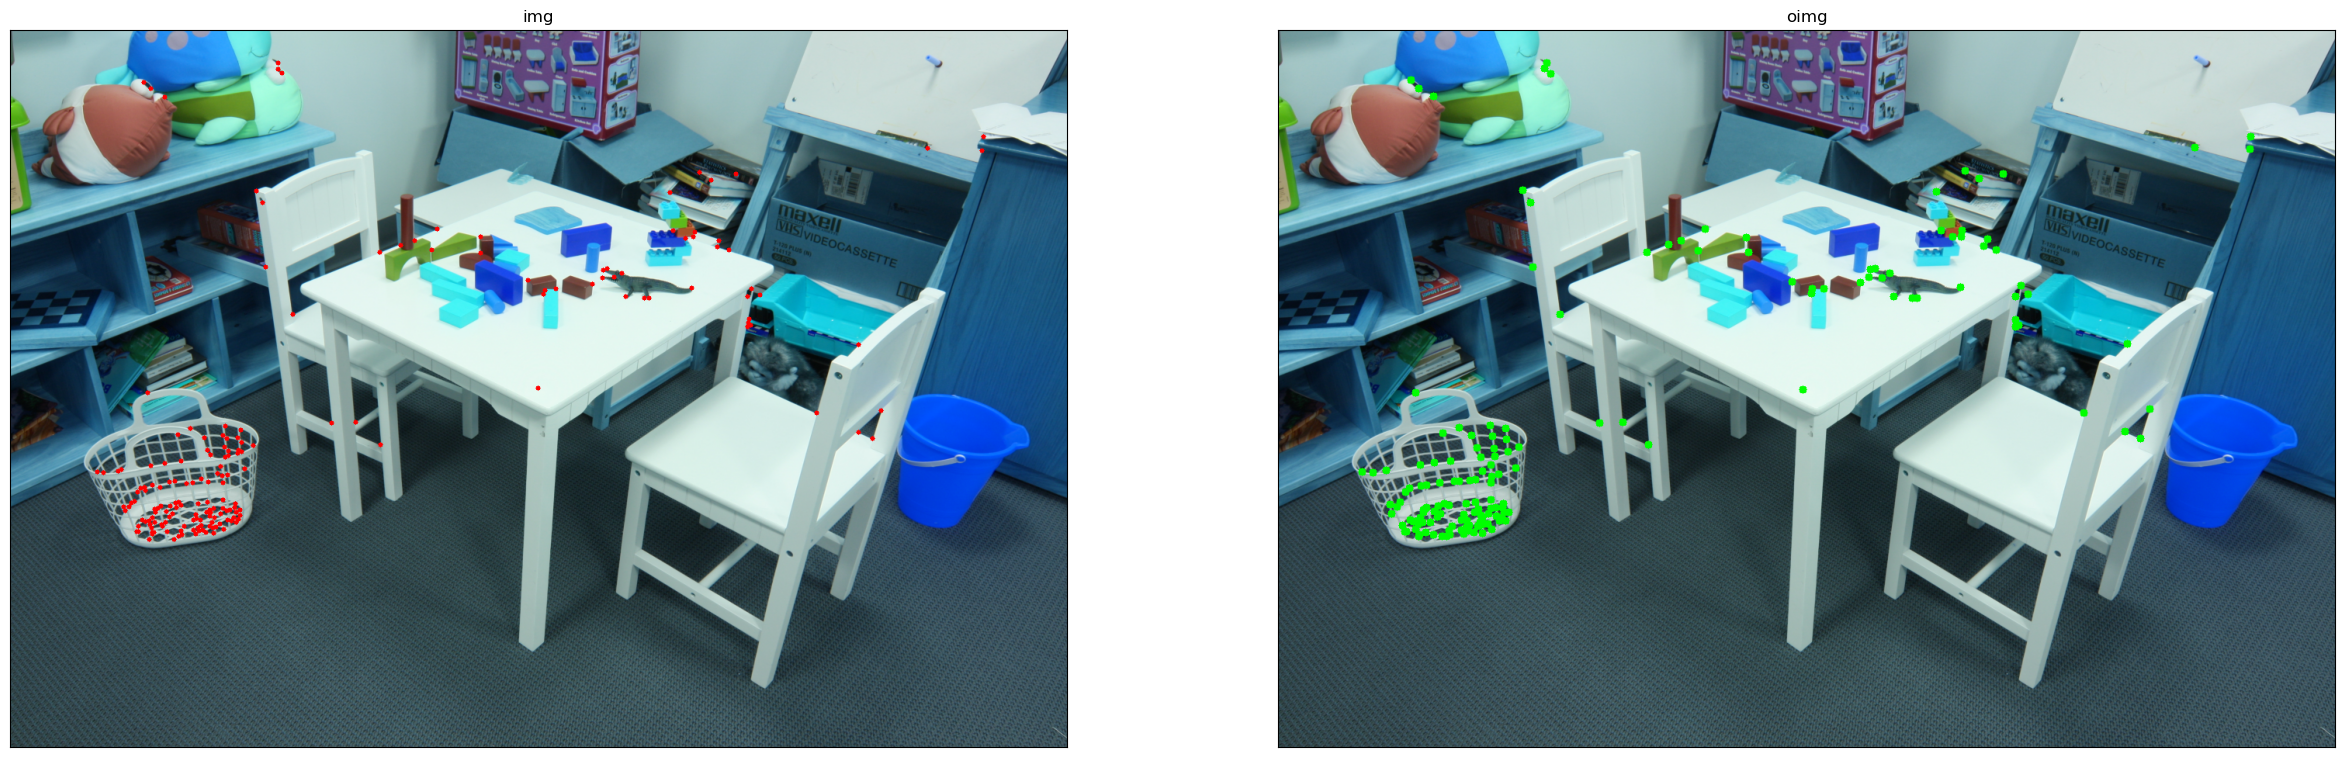

In [22]:
plt.figure(figsize = (30,45))
plt.subplot(1,2,1),plt.imshow(img)
plt.title('img'), plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2),plt.imshow(oimg)
plt.title('oimg'), plt.xticks([]), plt.yticks([])
plt.show()

In [18]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

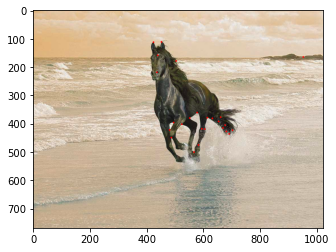

(<matplotlib.image.AxesImage at 0x19e3ec14850>, None)

In [19]:
img = cv2.imread('horse-beach.bmp')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
corners = cv2.goodFeaturesToTrack(gray,25,0.01,10)
corners = np.int0(corners)
for i in corners:
    x,y = i.ravel()
    cv2.circle(img,(x,y),3,255,-1)
plt.imshow(img),plt.show()

In [20]:
img = cv2.imread('sim2.png')
gray= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
kp = sift.detect(gray,None)
imgsift = cv2.imread('sim2.png')
imgsiftrich = cv2.imread('sim2.png')
imgsiftrich=cv2.drawKeypoints(img,kp,imgsiftrich,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
imgsift=cv2.drawKeypoints(img,kp,imgsift)

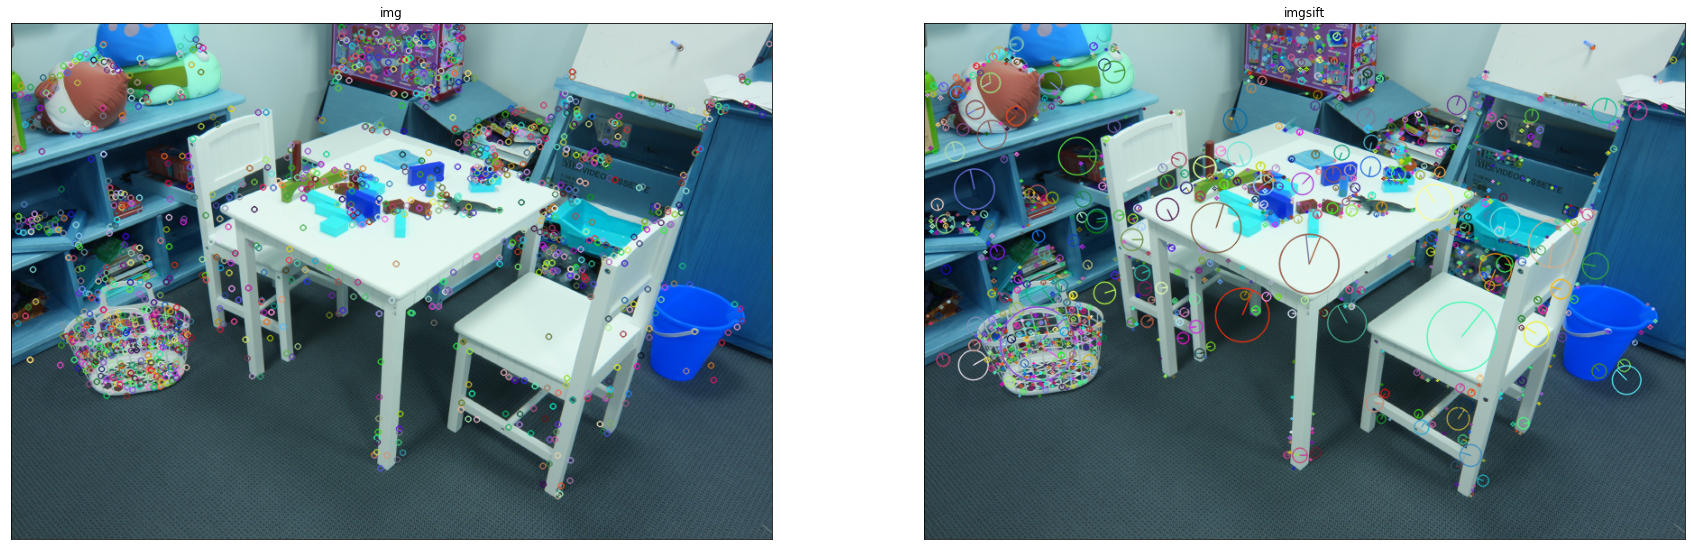

In [21]:
plt.figure(figsize = (30,45))
plt.subplot(1,2,1),plt.imshow(imgsift)
plt.title('img'), plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2),plt.imshow(imgsiftrich)
plt.title('imgsift'), plt.xticks([]), plt.yticks([])
plt.show()